# Feature Investigation and Selection

Investigate the 43 candidate features produced by `2_feature_engineer.ipynb` and select a justified subset via RF importance ranking + correlation pruning.

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from app.data import time_based_split, load_features
from app.config import FEATURES_PATH, TEST_FRAC, RANDOM_SEED

df = load_features(FEATURES_PATH)
X_train, X_test, y_train, y_test = time_based_split(df, test_frac=TEST_FRAC)
print(f"Train: {len(X_train):,} rows, {X_train.shape[1]} candidate features")


Train: 5,090,096 rows, 43 candidate features


## Step 2: Fit a quick RF probe and extract importances

Expect ~1-2 minutes on the full ~5M-row training set with 50 trees.

In [2]:
rf_probe = RandomForestClassifier(n_estimators=50, class_weight="balanced", random_state=RANDOM_SEED, n_jobs=-1)
rf_probe.fit(X_train, y_train)

importances = pd.Series(rf_probe.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(importances)


is_amount_equal_oldbalanceOrig    2.457876e-01
orig_balance_change_abs_error     1.561283e-01
isOrigBalanceEnough               7.634767e-02
errorBalanceOrig                  6.660876e-02
amount_to_orig_ratio              6.628221e-02
balance_drop_ratio                5.853010e-02
isNewBalanceOrigZero              5.724840e-02
orig_balance_after_expected       5.028120e-02
orig_balance_change               4.787167e-02
is_transfer_or_cashout            4.306637e-02
is_full_balance_transfer          2.624728e-02
amount_to_dest_cum_avg_ratio      1.764575e-02
amount_to_dest_ratio              1.474661e-02
amount                            1.163008e-02
type_PAYMENT                      1.061209e-02
is_merchant_dest                  9.867453e-03
amount_to_orig_avg_ratio          6.839618e-03
errorBalanceDest                  5.484504e-03
type_TRANSFER                     4.822271e-03
amount_to_dest_avg_ratio          3.517146e-03
isNewBalanceDestZero              3.023013e-03
type_CASH_OUT

## Step 3: Correlation pruning (|corr| > 0.9)

In [3]:
corr_matrix = X_train.corr().abs()
to_drop = set()
cols = list(corr_matrix.columns)
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        c1, c2 = cols[i], cols[j]
        if corr_matrix.loc[c1, c2] > 0.9:
            loser = c1 if importances[c1] < importances[c2] else c2
            to_drop.add(loser)

print(f"Dropping {len(to_drop)} correlated features: {sorted(to_drop)}")
remaining = [c for c in importances.index if c not in to_drop]
print(f"{len(remaining)} features remain after correlation pruning")


Dropping 9 correlated features: ['amount', 'amount_to_dest_avg_ratio', 'amount_to_orig_avg_ratio', 'dest_cum_count', 'errorBalanceOrig', 'isNewBalanceDestZero', 'is_full_balance_transfer', 'is_merchant_dest', 'orig_cum_avg']
34 features remain after correlation pruning


## Step 4: Pick the importance elbow and finalize the list

In [4]:
remaining_importances = importances[remaining]
print(remaining_importances)


is_amount_equal_oldbalanceOrig    2.457876e-01
orig_balance_change_abs_error     1.561283e-01
isOrigBalanceEnough               7.634767e-02
amount_to_orig_ratio              6.628221e-02
balance_drop_ratio                5.853010e-02
isNewBalanceOrigZero              5.724840e-02
orig_balance_after_expected       5.028120e-02
orig_balance_change               4.787167e-02
is_transfer_or_cashout            4.306637e-02
amount_to_dest_cum_avg_ratio      1.764575e-02
amount_to_dest_ratio              1.474661e-02
type_PAYMENT                      1.061209e-02
errorBalanceDest                  5.484504e-03
type_TRANSFER                     4.822271e-03
type_CASH_OUT                     2.825545e-03
is_large_amount                   2.472590e-03
hour_of_day                       2.391269e-03
dest_balance_change               2.262887e-03
dest_balance_after_expected       2.042533e-03
dest_balance_change_abs_error     1.110787e-03
isDestBalanceZero                 8.458989e-04
type_CASH_IN 

Matplotlib is building the font cache; this may take a moment.


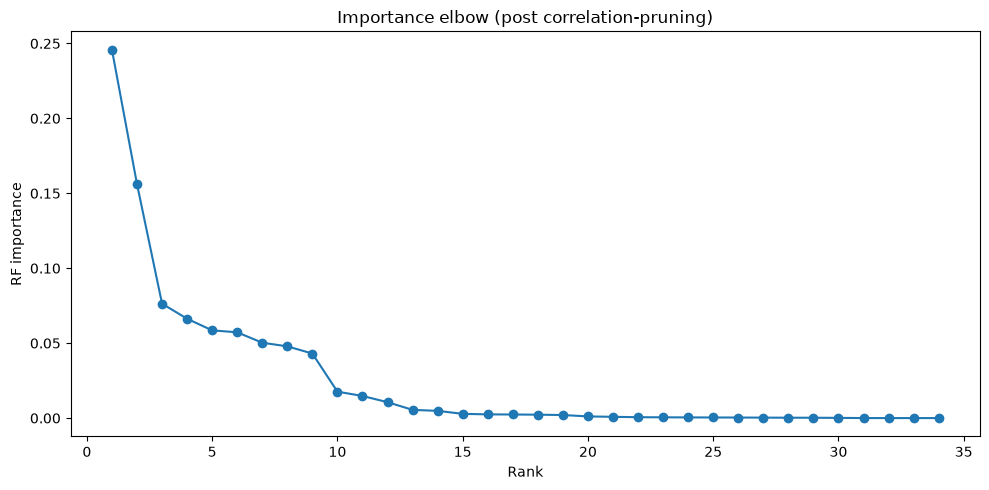

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(remaining_importances) + 1), remaining_importances.values, marker="o")
ax.set_xlabel("Rank")
ax.set_ylabel("RF importance")
ax.set_title("Importance elbow (post correlation-pruning)")
plt.tight_layout()
plt.show()


In [6]:
# N chosen by inspecting the printed ranked list / elbow plot above.
N = 20
SELECTED_FEATURES = remaining_importances.head(N).index.tolist()
print(SELECTED_FEATURES)


['is_amount_equal_oldbalanceOrig', 'orig_balance_change_abs_error', 'isOrigBalanceEnough', 'amount_to_orig_ratio', 'balance_drop_ratio', 'isNewBalanceOrigZero', 'orig_balance_after_expected', 'orig_balance_change', 'is_transfer_or_cashout', 'amount_to_dest_cum_avg_ratio', 'amount_to_dest_ratio', 'type_PAYMENT', 'errorBalanceDest', 'type_TRANSFER', 'type_CASH_OUT', 'is_large_amount', 'hour_of_day', 'dest_balance_change', 'dest_balance_after_expected', 'dest_balance_change_abs_error']
